EDA DEL WORKSOP 2

In [200]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.feature_selection import SelectKBest, f_regression
from scipy.stats import f_oneway

Se leen los csv de losd atos de los años para ver su contenido en esete ejemplo los vamos ahcer por años para mayor entendiemitno
de cada uno de manera indivudual 


## csv año 2015

In [201]:
df_2015 = pd.read_csv('../data/raw/2015.csv', sep=",", encoding="utf-8")
df_2015

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302


### Tamaño del Dataset y Tipos de Datos

In [202]:
df_2015.shape

(158, 12)

El dataset correspondiente al año 2015 tiene un total de 158 registros (filas) y 12 columnas. Esto significa que hay información de 158 observaciones o entradas, cada una con 12 atributos o variables.

In [203]:
df_2015.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

El dataset del año 2015 contiene **158 registros** y **12 columnas**. A continuación, se describen los tipos de datos presentes:

- **Categóricos (`object`)**: 2 columnas
  - `Country`
  - `Region`
  
- **Numéricos (`int64` y `float64`)**: 10 columnas
  - `int64`: 1 columna (`Happiness Rank`)
  - `float64`: 9 columnas

## limpieza de los datos 

### Datos nulos


In [204]:
df_2015.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

Se realizó una verificación para identificar la presencia de datos nulos en cada columna del dataset. El resultado muestra que **ninguna de las 12 columnas contiene valores nulos**:

- Todas las columnas tienen un conteo de nulos igual a **0**.


### datos duplicados 

In [205]:
df_2015.duplicated().sum()

0

Se comprobó si existen filas duplicadas en el dataset utilizando `df_2015.duplicated().sum()`. El resultado fue:

- **0 filas duplicadas** encontradas.


### datos categoricos


In [206]:
uniruqe_country_2015 = df_2015['Country'].unique()
uniruqe_country_2015

array(['Switzerland', 'Iceland', 'Denmark', 'Norway', 'Canada', 'Finland',
       'Netherlands', 'Sweden', 'New Zealand', 'Australia', 'Israel',
       'Costa Rica', 'Austria', 'Mexico', 'United States', 'Brazil',
       'Luxembourg', 'Ireland', 'Belgium', 'United Arab Emirates',
       'United Kingdom', 'Oman', 'Venezuela', 'Singapore', 'Panama',
       'Germany', 'Chile', 'Qatar', 'France', 'Argentina',
       'Czech Republic', 'Uruguay', 'Colombia', 'Thailand',
       'Saudi Arabia', 'Spain', 'Malta', 'Taiwan', 'Kuwait', 'Suriname',
       'Trinidad and Tobago', 'El Salvador', 'Guatemala', 'Uzbekistan',
       'Slovakia', 'Japan', 'South Korea', 'Ecuador', 'Bahrain', 'Italy',
       'Bolivia', 'Moldova', 'Paraguay', 'Kazakhstan', 'Slovenia',
       'Lithuania', 'Nicaragua', 'Peru', 'Belarus', 'Poland', 'Malaysia',
       'Croatia', 'Libya', 'Russia', 'Jamaica', 'North Cyprus', 'Cyprus',
       'Algeria', 'Kosovo', 'Turkmenistan', 'Mauritius', 'Hong Kong',
       'Estonia', 'Indonesi

In [207]:
df_2015['Country'].nunique()

158

Se evaluó la columna `Country` para identificar los valores únicos correspondientes a los países presentes en el dataset del año 2015.

- La columna `Country` es de tipo **categórico**.
- Contiene **158 valores únicos**, lo que indica que **cada fila del dataset representa un país distinto**.

In [208]:
uniruqe_region_2015= df_2015['Region'].unique()
uniruqe_region_2015

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Middle East and Northern Africa', 'Latin America and Caribbean',
       'Southeastern Asia', 'Central and Eastern Europe', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia'], dtype=object)

In [209]:
df_2015['Region'].nunique()

10

La columna `Region` representa la región geográfica de cada país y es de tipo **categórico**.

#### Análisis de Correlación con la Variable Objetivo `Happiness Score` en 2015

In [210]:
numerical_cols_2015 = [
    'Happiness Score',
    'Standard Error',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity',
    'Dystopia Residual'
]

df_numeric = df_2015[numerical_cols_2015]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Happiness Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)




Correlaciones con Happiness Score:
Happiness Score                  1.000000
Economy (GDP per Capita)         0.780966
Family                           0.740605
Health (Life Expectancy)         0.724200
Freedom                          0.568211
Dystopia Residual                0.530474
Trust (Government Corruption)    0.395199
Generosity                       0.180319
Standard Error                  -0.177254
Name: Happiness Score, dtype: float64


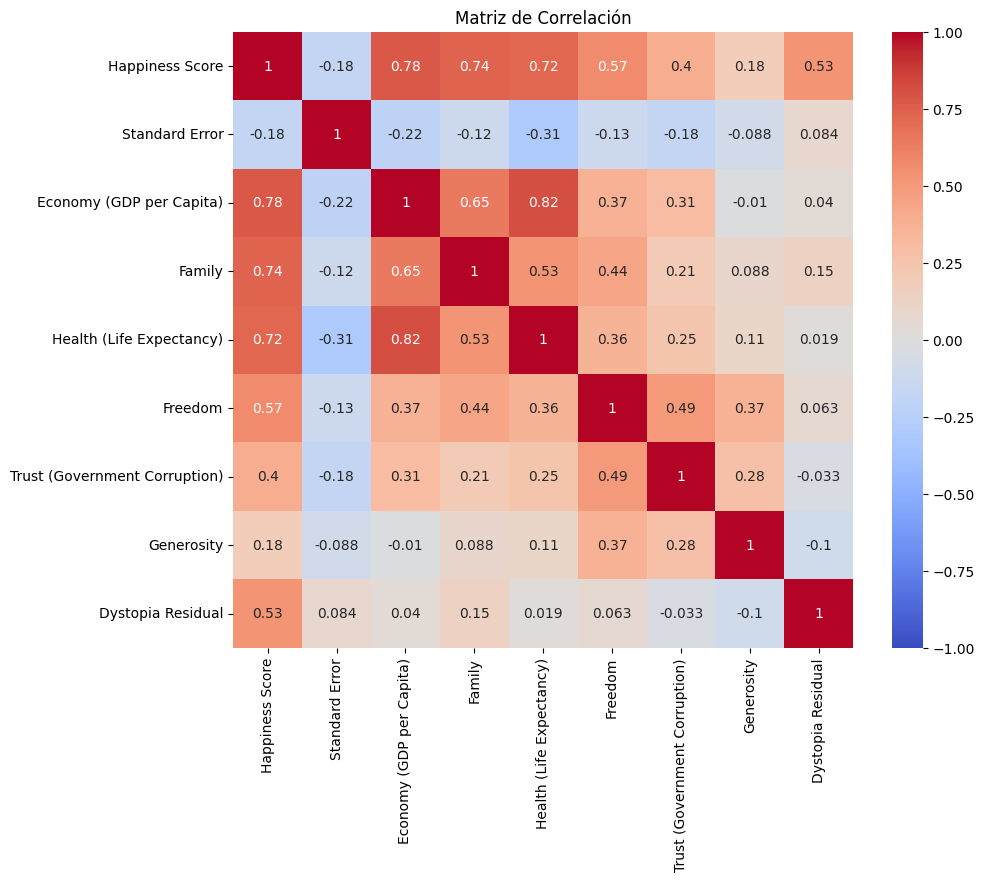

In [211]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

Al analizar la correlación entre las variables numéricas y el puntaje de felicidad (`Happiness Score`) en el dataset del 2015, encontramos lo siguiente:

- **Economy (GDP per Capita)** tiene una correlación alta y positiva (0.78) con la felicidad, lo que indica que un mayor PIB per cápita está asociado con mayores niveles de felicidad en los países.
- **Family** también muestra una correlación fuerte y positiva (0.74), sugiriendo que el apoyo familiar contribuye significativamente a la felicidad.
- **Health (Life Expectancy)** tiene una correlación positiva considerable (0.72), lo que refleja que una mayor esperanza de vida está relacionada con mayor felicidad.
- **Freedom** muestra una correlación moderada positiva (0.57), indicando que la percepción de libertad es un factor importante para la felicidad.
- **Dystopia Residual** tiene una correlación positiva moderada (0.53), aunque es una medida derivada, también se asocia con el nivel de felicidad.
- **Trust (Government Corruption)** presenta una correlación más baja pero positiva (0.39), lo que sugiere que mayor confianza en el gobierno contribuye a la felicidad, aunque en menor medida.
- **Generosity** tiene una correlación positiva débil (0.18), indicando que la generosidad tiene un impacto menor en la felicidad comparado con otras variables.
- Por último, **Standard Error** tiene una correlación negativa (-0.18), lo que implica que mayores errores estándar están asociados a valores menos fiables del puntaje de felicidad.

## dataset 2016

In [212]:
df_2016 = pd.read_csv('../data/raw/2016.csv', sep=",", encoding="utf-8")
df_2016

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596
...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Benin,Sub-Saharan Africa,153,3.484,3.404,3.564,0.39499,0.10419,0.21028,0.39747,0.06681,0.20180,2.10812
153,Afghanistan,Southern Asia,154,3.360,3.288,3.432,0.38227,0.11037,0.17344,0.16430,0.07112,0.31268,2.14558
154,Togo,Sub-Saharan Africa,155,3.303,3.192,3.414,0.28123,0.00000,0.24811,0.34678,0.11587,0.17517,2.13540
155,Syria,Middle East and Northern Africa,156,3.069,2.936,3.202,0.74719,0.14866,0.62994,0.06912,0.17233,0.48397,0.81789


Como vemos a diferencia del otro dataset, hay menos columnas,cuales columans faltan en el entrior dataset y cauales son iguales para determinar la columnas optimas para elvmodelo 

### Tamaño del dataset y los tipos de datos que hay en el mismos

In [213]:
df_2016.shape

(157, 13)

Para el dataframe del 2016 hay 157 filas y 13 columnas

In [214]:
df_2016.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

En total hay **2 columnas categóricas** y **11 columnas numéricas** en el dataset de 2016.

### limpieza de los de los datos

#### Datos nulos

In [215]:
df_2016.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

Se realizó una verificación para identificar la presencia de datos nulos en cada columna del dataset. El resultado muestra que **ninguna de las 13 columnas contiene valores nulos**:

- Todas las columnas tienen un conteo de nulos igual a **0**.

#### datos duplicados

In [216]:
df_2016.duplicated().sum()

0

Se comprobó si existen filas duplicadas en el dataset utilizando `df_2016.duplicated().sum()`. El resultado fue:

- **0 filas duplicadas** encontradas.

#### datos categoricos

In [217]:
uniruqe_country_2016 = df_2016['Country'].unique()
uniruqe_country_2016

array(['Denmark', 'Switzerland', 'Iceland', 'Norway', 'Finland', 'Canada',
       'Netherlands', 'New Zealand', 'Australia', 'Sweden', 'Israel',
       'Austria', 'United States', 'Costa Rica', 'Puerto Rico', 'Germany',
       'Brazil', 'Belgium', 'Ireland', 'Luxembourg', 'Mexico',
       'Singapore', 'United Kingdom', 'Chile', 'Panama', 'Argentina',
       'Czech Republic', 'United Arab Emirates', 'Uruguay', 'Malta',
       'Colombia', 'France', 'Thailand', 'Saudi Arabia', 'Taiwan',
       'Qatar', 'Spain', 'Algeria', 'Guatemala', 'Suriname', 'Kuwait',
       'Bahrain', 'Trinidad and Tobago', 'Venezuela', 'Slovakia',
       'El Salvador', 'Malaysia', 'Nicaragua', 'Uzbekistan', 'Italy',
       'Ecuador', 'Belize', 'Japan', 'Kazakhstan', 'Moldova', 'Russia',
       'Poland', 'South Korea', 'Bolivia', 'Lithuania', 'Belarus',
       'North Cyprus', 'Slovenia', 'Peru', 'Turkmenistan', 'Mauritius',
       'Libya', 'Latvia', 'Cyprus', 'Paraguay', 'Romania', 'Estonia',
       'Jamaica', 'Croa

In [218]:
df_2016['Country'].nunique()

157

Se evaluó la columna `Country` para identificar los valores únicos correspondientes a los países presentes en el dataset del año 2016.

- La columna `Country` es de tipo **categórico**.
- Contiene **157 valores únicos**, lo que indica que **cada fila del dataset representa un país distinto**.

Evaluar en comparacion al 2015, en 2016 hay uuno menos

In [219]:
uniruqe_region_2016 = df_2016['Region'].unique()
uniruqe_region_2016

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Middle East and Northern Africa', 'Latin America and Caribbean',
       'Southeastern Asia', 'Central and Eastern Europe', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia'], dtype=object)

In [220]:
df_2016['Region'].nunique()

10

La columna `Region` representa la región geográfica de cada país y es de tipo **categórico**, Hay 10 regiones en est dataset

#### Análisis de Correlación con la Variable Objetivo `Happiness Score` en 2016

In [221]:
numerical_cols_2016= [
    'Happiness Score',
    'Lower Confidence Interval',
    'Upper Confidence Interval',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity',
    'Dystopia Residual'
]

df_numeric = df_2016[numerical_cols_2016]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Happiness Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)



Correlaciones con Happiness Score:
Happiness Score                  1.000000
Lower Confidence Interval        0.999485
Upper Confidence Interval        0.999474
Economy (GDP per Capita)         0.790322
Health (Life Expectancy)         0.765384
Family                           0.739252
Freedom                          0.566827
Dystopia Residual                0.543738
Trust (Government Corruption)    0.402032
Generosity                       0.156848
Name: Happiness Score, dtype: float64


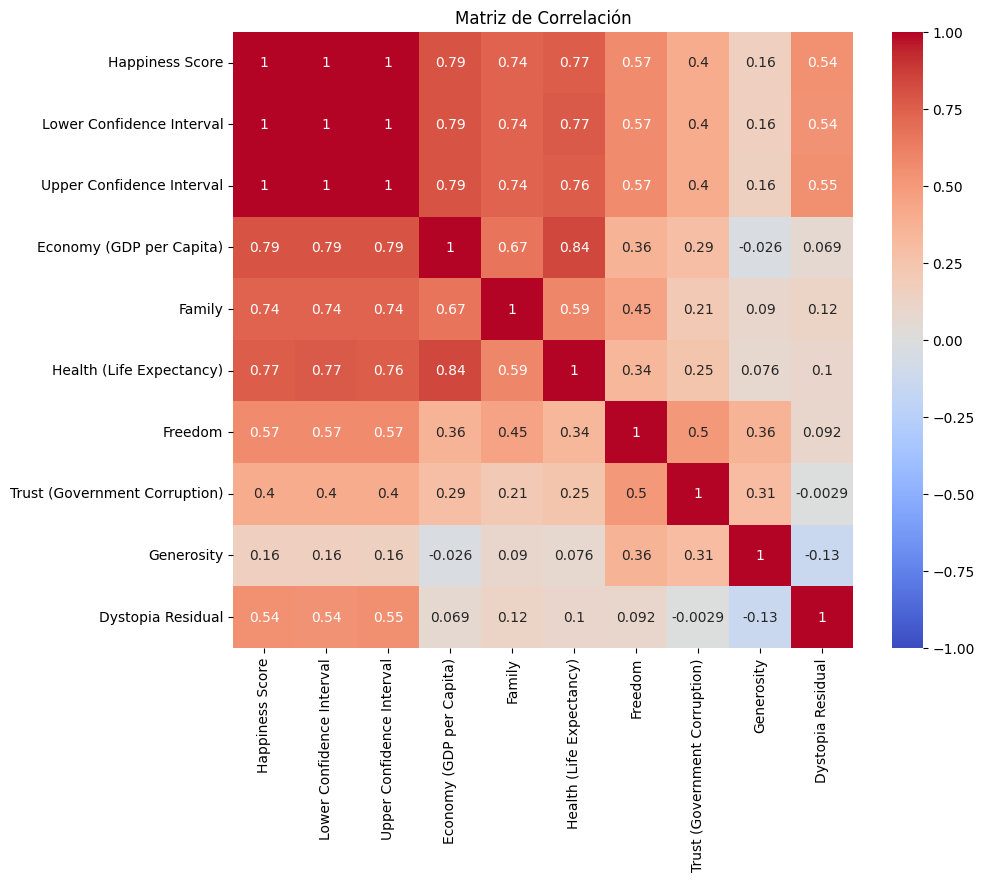

In [222]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

Las **confianzas inferior y superior** tienen una correlación casi perfecta con la puntuación de felicidad, lo cual es esperado dado que son intervalos relacionados directamente con esa variable.
- **Economía (GDP per Capita)**, **salud (esperanza de vida)** y **familia** muestran una fuerte correlación positiva con la felicidad, indicando que a mayor desarrollo económico, mejor salud y mayor soporte familiar, mayor es la percepción de felicidad.
- La **libertad** y el **residual de distopía** tienen una correlación positiva moderada.
- La **confianza en el gobierno** muestra una correlación baja a moderada.
- La **generosidad** tiene una correlación baja, indicando que su relación con la felicidad es menos significativa en este dataset.

## 2017

In [223]:
df_2017 = pd.read_csv('../data/raw/2016.csv', sep=",", encoding="utf-8")
df_2017

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596
...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Benin,Sub-Saharan Africa,153,3.484,3.404,3.564,0.39499,0.10419,0.21028,0.39747,0.06681,0.20180,2.10812
153,Afghanistan,Southern Asia,154,3.360,3.288,3.432,0.38227,0.11037,0.17344,0.16430,0.07112,0.31268,2.14558
154,Togo,Sub-Saharan Africa,155,3.303,3.192,3.414,0.28123,0.00000,0.24811,0.34678,0.11587,0.17517,2.13540
155,Syria,Middle East and Northern Africa,156,3.069,2.936,3.202,0.74719,0.14866,0.62994,0.06912,0.17233,0.48397,0.81789


### Tamaño del Dataset y Tipos de Datos

In [224]:
df_2017.shape

(157, 13)

El dataset del año 2017 contiene **157 filas** y **13 columnas**.

In [225]:
df_2017.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

En total, hay **2 columnas de tipo categórico (object)** y **11 columnas numéricas** (int64 y float64).

### limpieza de los de los datos

#### Datos nulos

In [226]:
df_2017.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

Se realizó una verificación para identificar la presencia de datos nulos en cada columna del dataset. El resultado muestra que **ninguna de las 9 columnas contiene valores nulos**:

- Todas las columnas tienen un conteo de nulos igual a **0**.

#### datos duplicados

In [227]:
df_2017.duplicated().sum()

0

Se comprobó si existen filas duplicadas en el dataset utilizando `df_2017.duplicated().sum()`. El resultado fue:

- **0 filas duplicadas** encontradas.

### datos categoricos

In [228]:
uniruqe_country_2017 = df_2017['Country'].unique()
uniruqe_country_2017

array(['Denmark', 'Switzerland', 'Iceland', 'Norway', 'Finland', 'Canada',
       'Netherlands', 'New Zealand', 'Australia', 'Sweden', 'Israel',
       'Austria', 'United States', 'Costa Rica', 'Puerto Rico', 'Germany',
       'Brazil', 'Belgium', 'Ireland', 'Luxembourg', 'Mexico',
       'Singapore', 'United Kingdom', 'Chile', 'Panama', 'Argentina',
       'Czech Republic', 'United Arab Emirates', 'Uruguay', 'Malta',
       'Colombia', 'France', 'Thailand', 'Saudi Arabia', 'Taiwan',
       'Qatar', 'Spain', 'Algeria', 'Guatemala', 'Suriname', 'Kuwait',
       'Bahrain', 'Trinidad and Tobago', 'Venezuela', 'Slovakia',
       'El Salvador', 'Malaysia', 'Nicaragua', 'Uzbekistan', 'Italy',
       'Ecuador', 'Belize', 'Japan', 'Kazakhstan', 'Moldova', 'Russia',
       'Poland', 'South Korea', 'Bolivia', 'Lithuania', 'Belarus',
       'North Cyprus', 'Slovenia', 'Peru', 'Turkmenistan', 'Mauritius',
       'Libya', 'Latvia', 'Cyprus', 'Paraguay', 'Romania', 'Estonia',
       'Jamaica', 'Croa

In [229]:
df_2017['Country'].nunique()

157

Se evaluó la columna `Country` para identificar los valores únicos correspondientes a los países presentes en el dataset del año 2017.

- La columna `Country` es de tipo **categórico**.
- Contiene **157 valores únicos**, lo que indica que **cada fila del dataset representa un país distinto**.

In [230]:
uniruqe_region_2017 = df_2017['Region'].unique()
uniruqe_region_2017

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Middle East and Northern Africa', 'Latin America and Caribbean',
       'Southeastern Asia', 'Central and Eastern Europe', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia'], dtype=object)

In [231]:
df_2017['Region'].nunique()

10

La columna `Region` representa la región geográfica de cada país y es de tipo **categórico** y hay 10 regiones

#### Análisis de Correlación con la Variable Objetivo `Happiness Score` en 2017

In [232]:
numerical_cols_2017= [
   'Happiness Score',
   'Lower Confidence Interval',
   'Upper Confidence Interval',
   'Economy (GDP per Capita)',
   'Family',
   'Health (Life Expectancy)',
   'Freedom',
   'Trust (Government Corruption)',
   'Generosity',
   'Dystopia Residual'
]


df_numeric = df_2017[numerical_cols_2017]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Happiness Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)


Correlaciones con Happiness Score:
Happiness Score                  1.000000
Lower Confidence Interval        0.999485
Upper Confidence Interval        0.999474
Economy (GDP per Capita)         0.790322
Health (Life Expectancy)         0.765384
Family                           0.739252
Freedom                          0.566827
Dystopia Residual                0.543738
Trust (Government Corruption)    0.402032
Generosity                       0.156848
Name: Happiness Score, dtype: float64


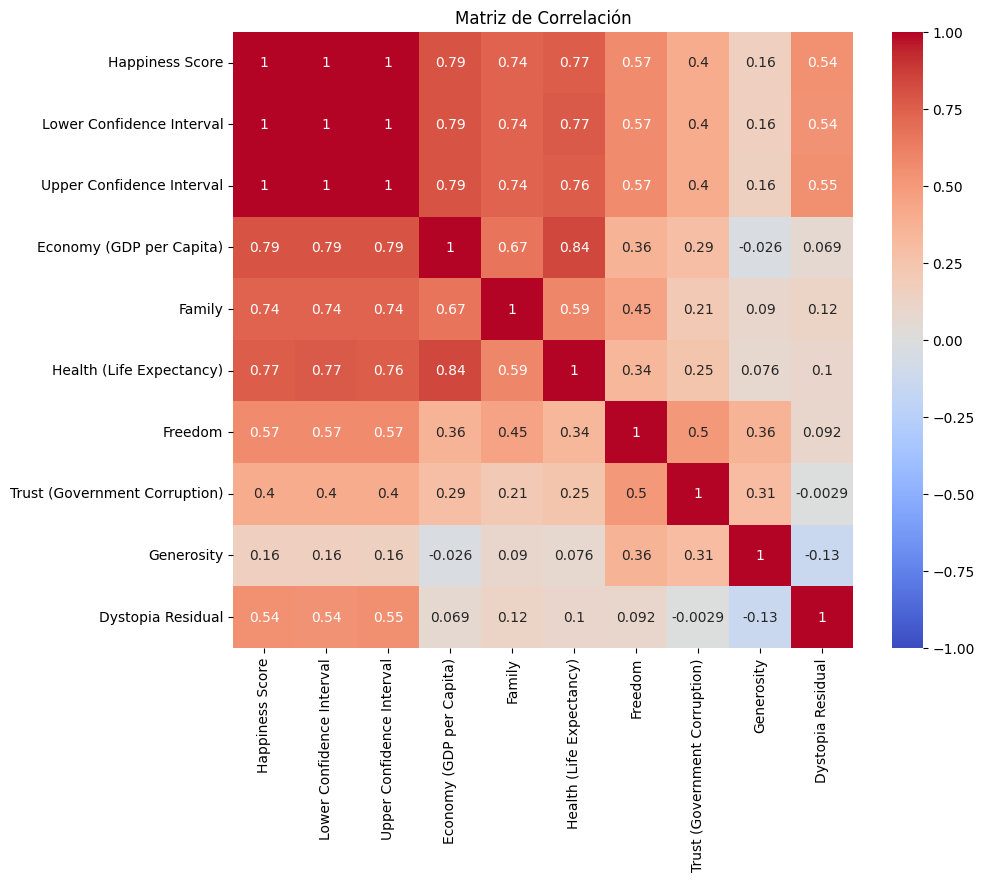

In [233]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

- La columna **Happiness Score** tiene una correlación perfecta consigo misma (1.0), como es esperado.

- Las columnas **Lower Confidence Interval** y **Upper Confidence Interval** muestran una correlación casi perfecta con el Happiness Score (0.9995 y 0.9995), lo que indica que los intervalos de confianza están muy estrechamente relacionados con la puntuación de felicidad.

- Las variables con mayor correlación positiva con Happiness Score son:
  - **Economy (GDP per Capita)**: 0.79  
  - **Health (Life Expectancy)**: 0.77  
  - **Family**: 0.74  
  - **Freedom**: 0.57  


## 2018

In [234]:
df_2018 = pd.read_csv('../data/raw/2018.csv', sep=",", encoding="utf-8")
df_2018

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357
...,...,...,...,...,...,...,...,...,...
151,152,Yemen,3.355,0.442,1.073,0.343,0.244,0.083,0.064
152,153,Tanzania,3.303,0.455,0.991,0.381,0.481,0.270,0.097
153,154,South Sudan,3.254,0.337,0.608,0.177,0.112,0.224,0.106
154,155,Central African Republic,3.083,0.024,0.000,0.010,0.305,0.218,0.038


### Tamaño del Dataset y Tipos de Datos

In [235]:
df_2018.shape

(156, 9)

El dataset del año 2018 contiene **156 filas** y **9 columnas**.

In [236]:
df_2018.dtypes

Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

En total, hay **1 column de tipo categórico (object)** y **8 columnas numéricas** (int64 y float64). Ademas que hay nombres de columnas que no coninciden con los daset anteriores

### limpieza de los de los datos

#### Datos nulos

In [237]:
df_2018.isnull().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       1
dtype: int64

Tner en cunta est nulo, para saber si esa columan es importante, cuando unamos los csv vamos a relizar otro analisis para determianar

#### datos duplicados

In [238]:
df_2018.duplicated().sum()

0

Se comprobó si existen filas duplicadas en el dataset utilizando `df_2018.duplicated().sum()`. El resultado fue:

- **0 filas duplicadas** encontradas.

### datos categoricos

In [239]:
uniruqe_country_2018 = df_2018['Country or region'].unique()
uniruqe_country_2018

array(['Finland', 'Norway', 'Denmark', 'Iceland', 'Switzerland',
       'Netherlands', 'Canada', 'New Zealand', 'Sweden', 'Australia',
       'United Kingdom', 'Austria', 'Costa Rica', 'Ireland', 'Germany',
       'Belgium', 'Luxembourg', 'United States', 'Israel',
       'United Arab Emirates', 'Czech Republic', 'Malta', 'France',
       'Mexico', 'Chile', 'Taiwan', 'Panama', 'Brazil', 'Argentina',
       'Guatemala', 'Uruguay', 'Qatar', 'Saudi Arabia', 'Singapore',
       'Malaysia', 'Spain', 'Colombia', 'Trinidad & Tobago', 'Slovakia',
       'El Salvador', 'Nicaragua', 'Poland', 'Bahrain', 'Uzbekistan',
       'Kuwait', 'Thailand', 'Italy', 'Ecuador', 'Belize', 'Lithuania',
       'Slovenia', 'Romania', 'Latvia', 'Japan', 'Mauritius', 'Jamaica',
       'South Korea', 'Northern Cyprus', 'Russia', 'Kazakhstan', 'Cyprus',
       'Bolivia', 'Estonia', 'Paraguay', 'Peru', 'Kosovo', 'Moldova',
       'Turkmenistan', 'Hungary', 'Libya', 'Philippines', 'Honduras',
       'Belarus', 'Turkey

In [240]:
df_2018['Country or region'].nunique()

156

En este dataset no se encuentra region, este debemos de imputar la region o caso no tener en cuenta esat columna

### Análisis de Correlación con la Variable Objetivo `Happiness Score` en 2018

In [241]:
numerical_cols_2018= [
   'Score',
   'GDP per capita',
   'Social support',
   'Healthy life expectancy',
   'Freedom to make life choices',
   'Generosity',
   'Perceptions of corruption'
]


df_numeric = df_2018[numerical_cols_2018]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)


Correlaciones con Happiness Score:
Score                           1.000000
GDP per capita                  0.802124
Healthy life expectancy         0.775814
Social support                  0.745760
Freedom to make life choices    0.544280
Perceptions of corruption       0.405292
Generosity                      0.135825
Name: Score, dtype: float64


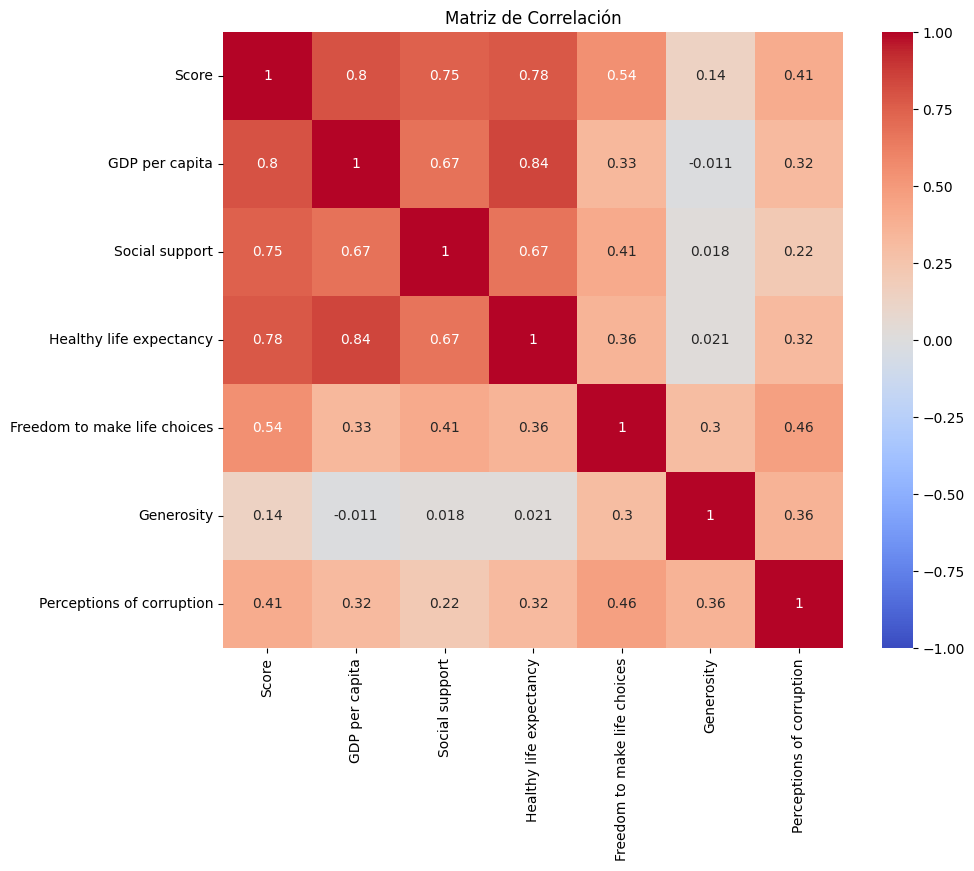

In [242]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

- La variable **Score** (puntuación de felicidad) tiene correlación perfecta consigo misma (1.0), como es esperado.

- Las variables con mayor correlación positiva con la puntuación de felicidad son:
  - **GDP per capita**: 0.80  
  - **Healthy life expectancy**: 0.78  
  - **Social support**: 0.75 

## 2019

In [243]:
df_2019 = pd.read_csv('../data/raw/2019.csv', sep=",", encoding="utf-8")
df_2019

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


### Tamaño del Dataset y Tipos de Datos

In [244]:
df_2019.shape

(156, 9)

El dataset del año 2018 contiene **156 filas** y **9 columnas**.

In [245]:
df_2019.dtypes

Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

En total, hay **1 column de tipo categórico (object)** y **8 columnas numéricas** (int64 y float64).

### limpieza de los de los datos

#### Datos nulos

In [246]:
df_2019.isnull().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

Se realizó una verificación para identificar la presencia de datos nulos en cada columna del dataset. El resultado muestra que **ninguna de las 9 columnas contiene valores nulos**:

- Todas las columnas tienen un conteo de nulos igual a **0**.

#### datos duplicados

In [247]:
df_2019.duplicated().sum()

0

Se comprobó si existen filas duplicadas en el dataset utilizando `df_2019.duplicated().sum()`. El resultado fue:

- **0 filas duplicadas** encontradas.

### datos categoricos

In [248]:
uniruqe_country_2019= df_2019['Country or region'].unique()
uniruqe_country_2019

array(['Finland', 'Denmark', 'Norway', 'Iceland', 'Netherlands',
       'Switzerland', 'Sweden', 'New Zealand', 'Canada', 'Austria',
       'Australia', 'Costa Rica', 'Israel', 'Luxembourg',
       'United Kingdom', 'Ireland', 'Germany', 'Belgium', 'United States',
       'Czech Republic', 'United Arab Emirates', 'Malta', 'Mexico',
       'France', 'Taiwan', 'Chile', 'Guatemala', 'Saudi Arabia', 'Qatar',
       'Spain', 'Panama', 'Brazil', 'Uruguay', 'Singapore', 'El Salvador',
       'Italy', 'Bahrain', 'Slovakia', 'Trinidad & Tobago', 'Poland',
       'Uzbekistan', 'Lithuania', 'Colombia', 'Slovenia', 'Nicaragua',
       'Kosovo', 'Argentina', 'Romania', 'Cyprus', 'Ecuador', 'Kuwait',
       'Thailand', 'Latvia', 'South Korea', 'Estonia', 'Jamaica',
       'Mauritius', 'Japan', 'Honduras', 'Kazakhstan', 'Bolivia',
       'Hungary', 'Paraguay', 'Northern Cyprus', 'Peru', 'Portugal',
       'Pakistan', 'Russia', 'Philippines', 'Serbia', 'Moldova', 'Libya',
       'Montenegro', 'Tajikis

In [249]:
df_2019['Country or region'].nunique()

156

En este dataset no se encuentra region, este debemos de imputar la region o caso no tener en cuenta esat columna. debemos de resolver este problemas ya que ne dos daset no hay region 

### Análisis de Correlación con la Variable Objetivo `Happiness Score` en 2019

In [250]:
numerical_cols_2019= [
   'Score',
   'GDP per capita',
   'Social support',
   'Healthy life expectancy',
   'Freedom to make life choices',
   'Generosity',
   'Perceptions of corruption'
]


df_numeric = df_2019[numerical_cols_2019]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)


Correlaciones con Happiness Score:
Score                           1.000000
GDP per capita                  0.793883
Healthy life expectancy         0.779883
Social support                  0.777058
Freedom to make life choices    0.566742
Perceptions of corruption       0.385613
Generosity                      0.075824
Name: Score, dtype: float64


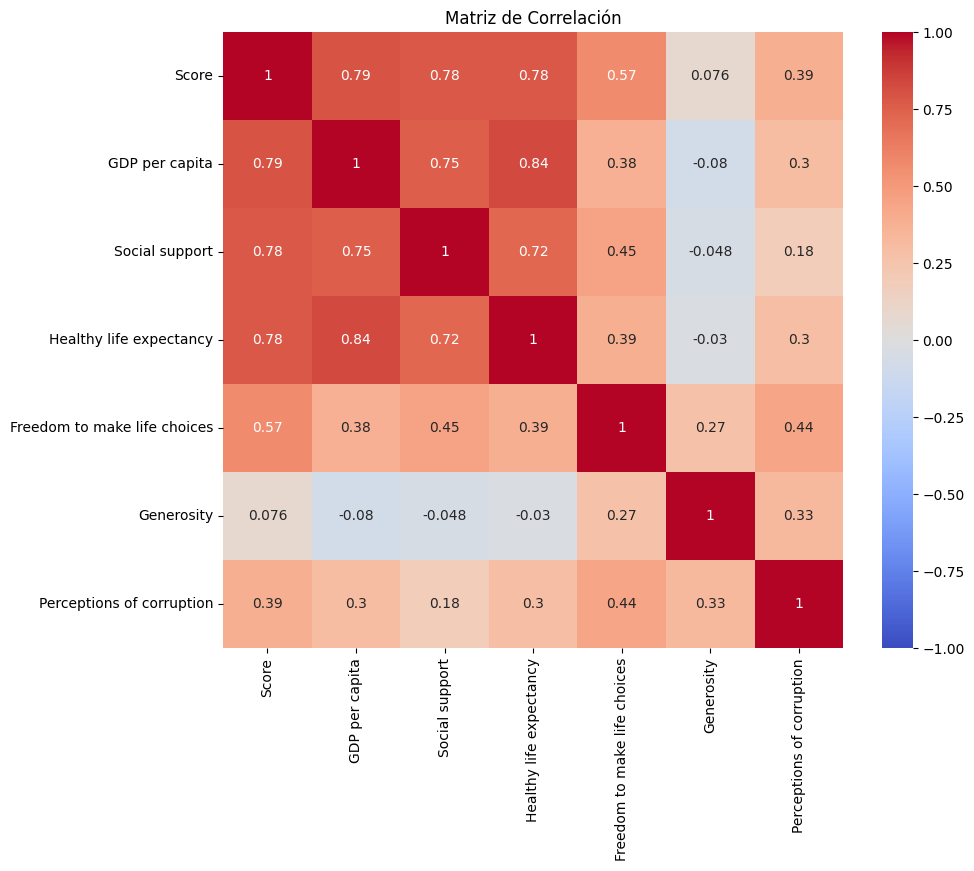

In [251]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

La variable **Score** (puntuación de felicidad) tiene correlación perfecta consigo misma (1.0), como se espera.

- Las variables con mayor correlación positiva con la puntuación de felicidad son:
  - **GDP per capita**: 0.79  
  - **Healthy life expectancy**: 0.78  
  - **Social support**: 0.78  

## Unir los dataset

In [252]:
dataframes= {
    "2015": df_2015,
    "2016": df_2016,
    "2017": df_2017,
    "2018": df_2018,
    "2019": df_2019
}

conjuntos_columnas = [set(df.columns) for df in dataframes.values()]

columnas_comunes_todos = set.intersection(*conjuntos_columnas)

print("Columnas comunes en los 5 datasets:")
print(columnas_comunes_todos)


Columnas comunes en los 5 datasets:
{'Generosity'}


Segun lo anterior la unica columna que tinene en comun los dastet este Genorosity, a lo que debemosexaminar cada columna detenimanete para saber que columnas vamos  aescoger, teniendo en encuneta que es para neterenar un modelo para la medidad de feliciada 

In [253]:

for (name1, df1), (name2, df2) in combinations(dataframes.items(), 2):
    columnas_1 = set(df1.columns)
    columnas_2 = set(df2.columns)
    
    comunes = columnas_1.intersection(columnas_2)
    solo_1 = columnas_1.difference(columnas_2)
    solo_2 = columnas_2.difference(columnas_1)
    
    print(f"--- Comparación entre {name1} y {name2} ---")
    print("Columnas comunes:", comunes)
    print(f"Columnas solo en {name1}:", solo_1)
    print(f"Columnas solo en {name2}:", solo_2)
    print("\n")

--- Comparación entre 2015 y 2016 ---
Columnas comunes: {'Region', 'Health (Life Expectancy)', 'Happiness Score', 'Dystopia Residual', 'Happiness Rank', 'Country', 'Family', 'Trust (Government Corruption)', 'Generosity', 'Freedom', 'Economy (GDP per Capita)'}
Columnas solo en 2015: {'Standard Error'}
Columnas solo en 2016: {'Upper Confidence Interval', 'Lower Confidence Interval'}


--- Comparación entre 2015 y 2017 ---
Columnas comunes: {'Region', 'Health (Life Expectancy)', 'Happiness Score', 'Dystopia Residual', 'Happiness Rank', 'Country', 'Family', 'Trust (Government Corruption)', 'Generosity', 'Freedom', 'Economy (GDP per Capita)'}
Columnas solo en 2015: {'Standard Error'}
Columnas solo en 2017: {'Upper Confidence Interval', 'Lower Confidence Interval'}


--- Comparación entre 2015 y 2018 ---
Columnas comunes: {'Generosity'}
Columnas solo en 2015: {'Region', 'Health (Life Expectancy)', 'Standard Error', 'Happiness Score', 'Dystopia Residual', 'Happiness Rank', 'Country', 'Family'

De lo anterior podemos decir que:

- Los datasets de **2015, 2016 y 2017** comparten prácticamente las mismas columnas, con algunas diferencias menores como la presencia de columnas de error estándar y de intervalos de confianza en algunos años.
  
- Los datasets de **2018 y 2019** tienen un esquema de columnas diferente al de los primeros tres años. Sin embargo, entre 2018 y 2019, las columnas son idénticas, lo que indica un cambio en la estructura de los datos a partir de 2018.

- Un indicio importante es que los últimos dos datasets (2018 y 2019) están relacionados entre sí en cuanto a las columnas, mientras que los tres primeros años comparten otro conjunto común de columnas, probablemente con denominaciones y variables similares.

Esto sugiere que a partir de 2018, el formato del dataset cambió, lo que implica que para realizar análisis comparativos entre años es necesario considerar estas diferencias en las columnas y adaptar el análisis según corresponda.

In [254]:
dataframes= {
    "2015": df_2015,
    "2016": df_2016,
    "2017": df_2017,
}

conjuntos_columnas = [set(df.columns) for df in dataframes.values()]

columnas_comunes_todos = set.intersection(*conjuntos_columnas)

print("Columnas comunes en los 3 datasets:")
print(columnas_comunes_todos)

Columnas comunes en los 3 datasets:
{'Region', 'Health (Life Expectancy)', 'Dystopia Residual', 'Happiness Rank', 'Country', 'Family', 'Economy (GDP per Capita)', 'Trust (Government Corruption)', 'Generosity', 'Freedom', 'Happiness Score'}


Como vemos, en los 3 primeros datasets existen estas columnas en común:

- `Region`
- `Economy (GDP per Capita)`
- `Trust (Government Corruption)`
- `Country`
- `Happiness Score`
- `Family`
- `Freedom`
- `Health (Life Expectancy)`
- `Generosity`
- `Happiness Rank`
- `Dystopia Residual`

Esto es bueno, ya que podemos armar un dataset unificado para estos 3 años, facilitando análisis comparativos y agregados sin preocuparnos por la inconsistencia en los nombres o la falta de columnas.

Ahora viene la organización de los 2 últimos datasets (2018 y 2019), los cuales tienen un esquema de columnas diferente, por lo que debemos identificar sus columnas comunes para también poder trabajar con un dataset unificado en esos años.


In [255]:
dataframes= {
    "2018": df_2018,
    "2019": df_2019
}

conjuntos_columnas = [set(df.columns) for df in dataframes.values()]

columnas_comunes_todos = set.intersection(*conjuntos_columnas)

print("Columnas comunes en los 2 datasets:")
print(columnas_comunes_todos)

Columnas comunes en los 2 datasets:
{'Perceptions of corruption', 'Social support', 'Healthy life expectancy', 'Country or region', 'Freedom to make life choices', 'Overall rank', 'GDP per capita', 'Generosity', 'Score'}


Como se observa, los datasets de 2018 y 2019 comparten las siguientes columnas:

- `Score`
- `Healthy life expectancy`
- `Social support`
- `GDP per capita`
- `Freedom to make life choices`
- `Generosity`
- `Perceptions of corruption`
- `Country or region`
- `Overall rank`

Todas estas columnas están presentes en ambos años, lo cual permite unificarlos para facilitar su análisis conjunto. 


In [256]:

column_rename_map = {
    'Country or region': 'Country',
    'Overall rank': 'Happiness Rank',
    'Score': 'Happiness Score',
    'GDP per capita': 'Economy (GDP per Capita)',
    'Social support': 'Family',
    'Healthy life expectancy': 'Health (Life Expectancy)',
    'Freedom to make life choices': 'Freedom',
    'Perceptions of corruption': 'Trust (Government Corruption)'
}

df_2018 = df_2018.rename(columns=column_rename_map)
df_2019 = df_2019.rename(columns=column_rename_map)


Con el objetivo de unificar todos los datasets de los años 2015 a 2019 y obtener la mayor cantidad de datos posibles, es necesario estandarizar los nombres de las columnas que representan las mismas variables pero que están nombradas de forma distinta en los años 2018 y 2019.

Con este paso, se estandarizan las columnas clave y se facilita la concatenación de los cinco datasets en un solo dataframe coherente y estructurado.

In [257]:
dataframes = {
    '2015': df_2015,
    '2016': df_2016,
    '2017': df_2017,
    '2018': df_2018,
    '2019': df_2019
}

conjuntos_columnas = [set(df.columns) for df in dataframes.values()]
columnas_comunes= set.intersection(*conjuntos_columnas)

print("Columnas comunes en los 5 datasets:")
print(columnas_comunes)


Columnas comunes en los 5 datasets:
{'Health (Life Expectancy)', 'Happiness Score', 'Happiness Rank', 'Country', 'Family', 'Generosity', 'Trust (Government Corruption)', 'Freedom', 'Economy (GDP per Capita)'}


Con los datasets de los años 2015 a 2019 ya estandarizados y renombrados correctamente, es posible identificar las columnas que se encuentran en común en los cinco años analizados. Estas columnas son:

A partir de esta coincidencia de columnas, y con base en la exploración de los datos realizada previamente, procedemos a construir un dataset unificado que contenga únicamente estas columnas comunes. Para ello, también realizaremos una limpieza básica asegurando que los datos estén listos para futuros análisis, como la imputación de valores nulos, la eliminación de duplicados y la verificación de tipos de datos adecuados.


In [258]:
columnas_comunes = ['Country', 'Happiness Score', 'Economy (GDP per Capita)','Happiness Rank',
                    'Family', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Health (Life Expectancy)']

dfs_filtrados = []


for año, df in dataframes.items():

    columnas_a_incluir = columnas_comunes.copy()  
    if 'Region' in df.columns:
        columnas_a_incluir.append('Region')  
    df_filtrado = df[columnas_a_incluir].copy()
    df_filtrado['Year'] = int(año)
    dfs_filtrados.append(df_filtrado)

df_unido = pd.concat(dfs_filtrados, ignore_index=True)

country_region_map = df_unido.groupby('Country')['Region'].agg(lambda x: x.mode()[0] if not x.mode().empty else pd.NA).to_dict()

df_unido['Region'] = df_unido['Country'].map(country_region_map)



Para construir un dataset unificado con la mayor cantidad de información posible, filtramos cada uno de los DataFrames originales (de 2015 a 2019) conservando únicamente las columnas comunes entre todos ellos. Estas columnas son:

- `Country`
- `Happiness Score`
- `Economy (GDP per Capita)`
- `Happiness Rank`
- `Family`
- `Freedom`
- `Trust (Government Corruption)`
- `Generosity`
- `Health (Life Expectancy)`

Adicionalmente, cuando la columna `Region` está presente en un dataset, también se incluye para no perder información contextual relevante. A cada fila se le añade una nueva columna llamada `Year`, que indica el año correspondiente del dato.


In [259]:
df_unido.shape

(784, 11)

El dataset unificado cuenta con un total de **784 registros (filas)** y **11 columnas**. Esta estructura consolida los datos de felicidad mundial de los años 2015 a 2019.


In [260]:
# Verificar valores nulos en 'Region' después del mapeo
print("Valores nulos en Region después del mapeo:")
print(df_unido['Region'].isnull().sum())

Valores nulos en Region después del mapeo:
6


Después de realizar el mapeo de regiones basado en el país, se identificó que existen **6 registros con valores nulos en la columna 'Region'**. Esto indica que para esos países no se logró asignar una región automáticamente, por lo cual será necesario corregir estos valores de forma manual o mediante una estrategia complementaria para asegurar la completitud del dataset.


In [261]:
nan_regions = df_unido[df_unido['Region'].isna()][['Country', 'Year']]

print("Countries with NaN in Region (6 rows):")
print(nan_regions)

print("\nTotal number of NaN values in Region:")
print(df_unido['Region'].isna().sum())

unique_countries = nan_regions['Country'].unique()
print("\nUnique countries with NaN in Region:")
print(unique_countries)

Countries with NaN in Region (6 rows):
               Country  Year
509  Trinidad & Tobago  2018
529    Northern Cyprus  2018
666  Trinidad & Tobago  2019
691    Northern Cyprus  2019
711    North Macedonia  2019
747             Gambia  2019

Total number of NaN values in Region:
6

Unique countries with NaN in Region:
['Trinidad & Tobago' 'Northern Cyprus' 'North Macedonia' 'Gambia']


Tras identificar los valores nulos en la columna **'Region'**, se encontraron **6 registros** con esta condición, correspondientes a los años **2018 y 2019**. Los países afectados.


In [262]:
manual_region_map = {
    'Trinidad & Tobago': 'Latin America and Caribbean',
    'Northern Cyprus': 'Middle East and Northern Africa',
    'North Macedonia': 'Central and Eastern Europe',
    'Gambia': 'Sub-Saharan Africa'
}

# Llenar los valores NaN en 'Region' usando el mapeo manual
df_unido['Region'] = df_unido['Region'].fillna(df_unido['Country'].map(manual_region_map))

# Verificar que no queden NaN en 'Region'
print("Valores nulos en Region después del mapeo manual:")
print(df_unido['Region'].isnull().sum())

Valores nulos en Region después del mapeo manual:
0


Para solucionar los valores nulos restantes en la columna **'Region'**, se realizó un mapeo manual asignando regiones apropiadas a los países afectados según su ubicación geográfica. El mapeo fue el siguiente:

- **Trinidad & Tobago** → *Latin America and Caribbean*
- **Northern Cyprus** → *Middle East and Northern Africa*
- **North Macedonia** → *Central and Eastern Europe*
- **Gambia** → *Sub-Saharan Africa*

Después de aplicar este mapeo, se verificó nuevamente la columna **'Region'** y se confirmó que **ya no existen valores nulos**, completando así la estandarización y limpieza del dataset unificado.


In [263]:
df_unido.dtypes

Country                           object
Happiness Score                  float64
Economy (GDP per Capita)         float64
Happiness Rank                     int64
Family                           float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Health (Life Expectancy)         float64
Region                            object
Year                               int64
dtype: object


- **2 columnas de tipo `object`**: `Country` y `Region`, que representan variables categóricas.
- **8 columnas de tipo numérico (`float64` y `int64`)**: corresponden a las variables utilizadas para calcular y analizar el puntaje de felicidad.
- **La columna `Year`**, aunque es de tipo `int64`, se tratará como una **variable categórica** ya que representa periodos discretos (años), no una medida continua.



In [264]:
df_unido.isnull().sum()

Country                          0
Happiness Score                  0
Economy (GDP per Capita)         0
Happiness Rank                   0
Family                           0
Freedom                          0
Trust (Government Corruption)    1
Generosity                       0
Health (Life Expectancy)         0
Region                           0
Year                             0
dtype: int64

In [265]:
df_unido = df_unido.dropna()


Al revisar los valores nulos en el dataset unificado, se encontró que solo la columna "Trust (Government Corruption)" presenta 1 valor faltante. Para asegurar la calidad y consistencia de los datos, se decidió eliminar la fila que contiene este valor nulo, quedando así el dataset limpio y listo para el análisis posterior.









In [266]:
df_2018.duplicated().sum()

0

No se encontraron datos duplicados en el dataset unificado, lo que garantiza que cada registro es único.

In [267]:
df_unido.shape

(783, 11)

Depues de hacer la limpieza del daset unido podemos hacer analisi descriptivo y de visualizaciones 

### Analisis descriptivo 

In [268]:
df_unido.describe().T

,count,mean,std,min,25%,50%,75%,max
Happiness Score,783.0,5.382820,1.129122,2.839,4.503500,5.33200,6.208500,7.76900
Economy (GDP per Capita),783.0,0.908532,0.402889,0.000,0.611510,0.97438,1.230555,1.82427
Happiness Rank,783.0,78.968072,45.275121,1.000,40.000000,79.00000,118.000000,158.00000
Family,783.0,0.999804,0.337583,0.000,0.790425,1.03143,1.240090,1.64400
Freedom,783.0,0.403670,0.152909,0.000,0.305000,0.41900,0.524500,0.72400
Trust (Government Corruption),783.0,0.128338,0.107764,0.000,0.054500,0.09314,0.161800,0.55191
Generosity,783.0,0.217838,0.122026,0.000,0.130000,0.20180,0.275355,0.81971
Health (Life Expectancy),783.0,0.613445,0.246701,0.000,0.440305,0.64718,0.808000,1.14100
Year,783.0,2016.992337,1.416000,2015.000,2016.000000,2017.00000,2018.000000,2019.00000




- El dataset contiene 783 registros con datos completos.
- **Happiness Score**: La puntuación promedio de felicidad es aproximadamente 5.38, con un rango desde 2.84 hasta 7.77, mostrando una desviación estándar moderada (1.13).
- **Economy (GDP per Capita)**: El valor promedio es 0.91, con valores que varían desde 0 hasta 1.82, indicando diferencias importantes en el PIB per cápita relativo.
- **Happiness Rank**: El rango medio es 79, con un mínimo de 1 (país más feliz) y un máximo de 158, mostrando amplia dispersión entre países.
- **Family** (Apoyo social): Promedio cercano a 1.0, con un mínimo de 0 y máximo de 1.64, reflejando variabilidad en el soporte familiar.
- **Freedom**: El promedio es 0.40, con valores entre 0 y 0.72, indicando diferencias en la percepción de libertad para tomar decisiones.
- **Trust (Government Corruption)**: Promedio bajo (0.13), con amplio rango (0 a 0.55), sugiriendo variación en la percepción de corrupción.
- **Generosity**: Promedio de 0.22, con valores desde 0 hasta 0.82, mostrando diversidad en los niveles de generosidad reportados.
- **Health (Life Expectancy)**: Promedio de 0.61, con un rango desde 0 hasta 1.14, indicando diferencias en la esperanza de vida saludable.



In [269]:
df_unido.describe(include='object').T

,count,unique,top,freq
Country,783,168,Switzerland,5
Region,783,10,Sub-Saharan Africa,195


- **Country**:
  - Total de registros: 783
  - Países únicos: 168
  - País más frecuente: *Switzerland* (aparece 5 veces)

- **Region**:
  - Total de registros: 783
  - Regiones únicas: 10
  - Región más frecuente: *Sub-Saharan Africa* (195 registros)

### outliders

In [270]:
numerical_cols = df_unido.select_dtypes(include=['int64', 'float64'])


for col in numerical_cols:
    print(f"\n--- Handling Outliers for {col} ---")

    Q1 = df_unido[col].quantile(0.25)
    Q3 = df_unido[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df_unido[(df_unido[col] < lower_limit) | (df_unido[col] > upper_limit)]
    print(f"Number of Outliers: {len(outliers)}")


--- Handling Outliers for Happiness Score ---
Number of Outliers: 0

--- Handling Outliers for Economy (GDP per Capita) ---
Number of Outliers: 0

--- Handling Outliers for Happiness Rank ---
Number of Outliers: 0

--- Handling Outliers for Family ---
Number of Outliers: 9

--- Handling Outliers for Freedom ---
Number of Outliers: 0

--- Handling Outliers for Trust (Government Corruption) ---
Number of Outliers: 60

--- Handling Outliers for Generosity ---
Number of Outliers: 23

--- Handling Outliers for Health (Life Expectancy) ---
Number of Outliers: 0

--- Handling Outliers for Year ---
Number of Outliers: 0


- No se detectaron outliers en las siguientes variables:
  - Happiness Score
  - Economy (GDP per Capita)
  - Happiness Rank
  - Freedom
  - Health (Life Expectancy)
  - Year

- Variables con outliers detectados:
  - Family: 9 outliers
  - Trust (Government Corruption): 60 outliers
  - Generosity: 23 outliers

  se toma la decions de dejar esos outliders por la poca cantidad de datos

## visualizaciones


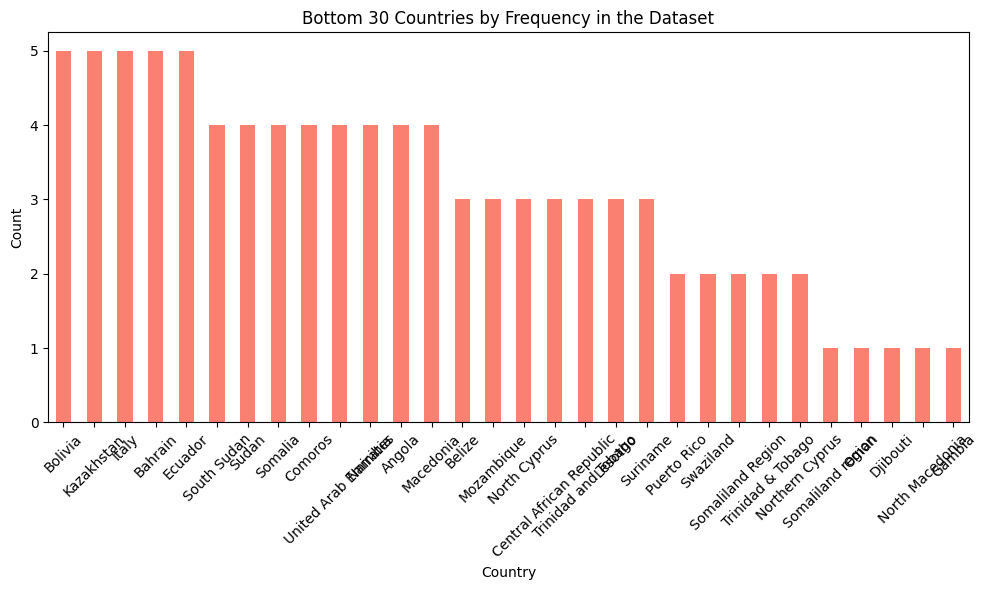

In [271]:

conteo_paises = df_unido['Country'].value_counts()

ultimos_10 = conteo_paises.tail(30)

ultimos_10.plot(kind='bar', figsize=(10, 6), color='salmon')
plt.title('Bottom 30 Countries by Frequency in the Dataset')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Se presentan los 30 países con menor frecuencia en el dataset entre 2015 y 2019, revelando que muchos aparecen solo en 3 o 4 de los 5 años, lo que refleja inconsistencias en la recolección de datos o cambios en nombres de países. Con ~165 países únicos, esta alta cardinalidad limita el uso de Country como variable predictiva. Por ello, el análisis destaca la importancia de un mapeo cuidadoso para mantener la consistencia en el estudio.

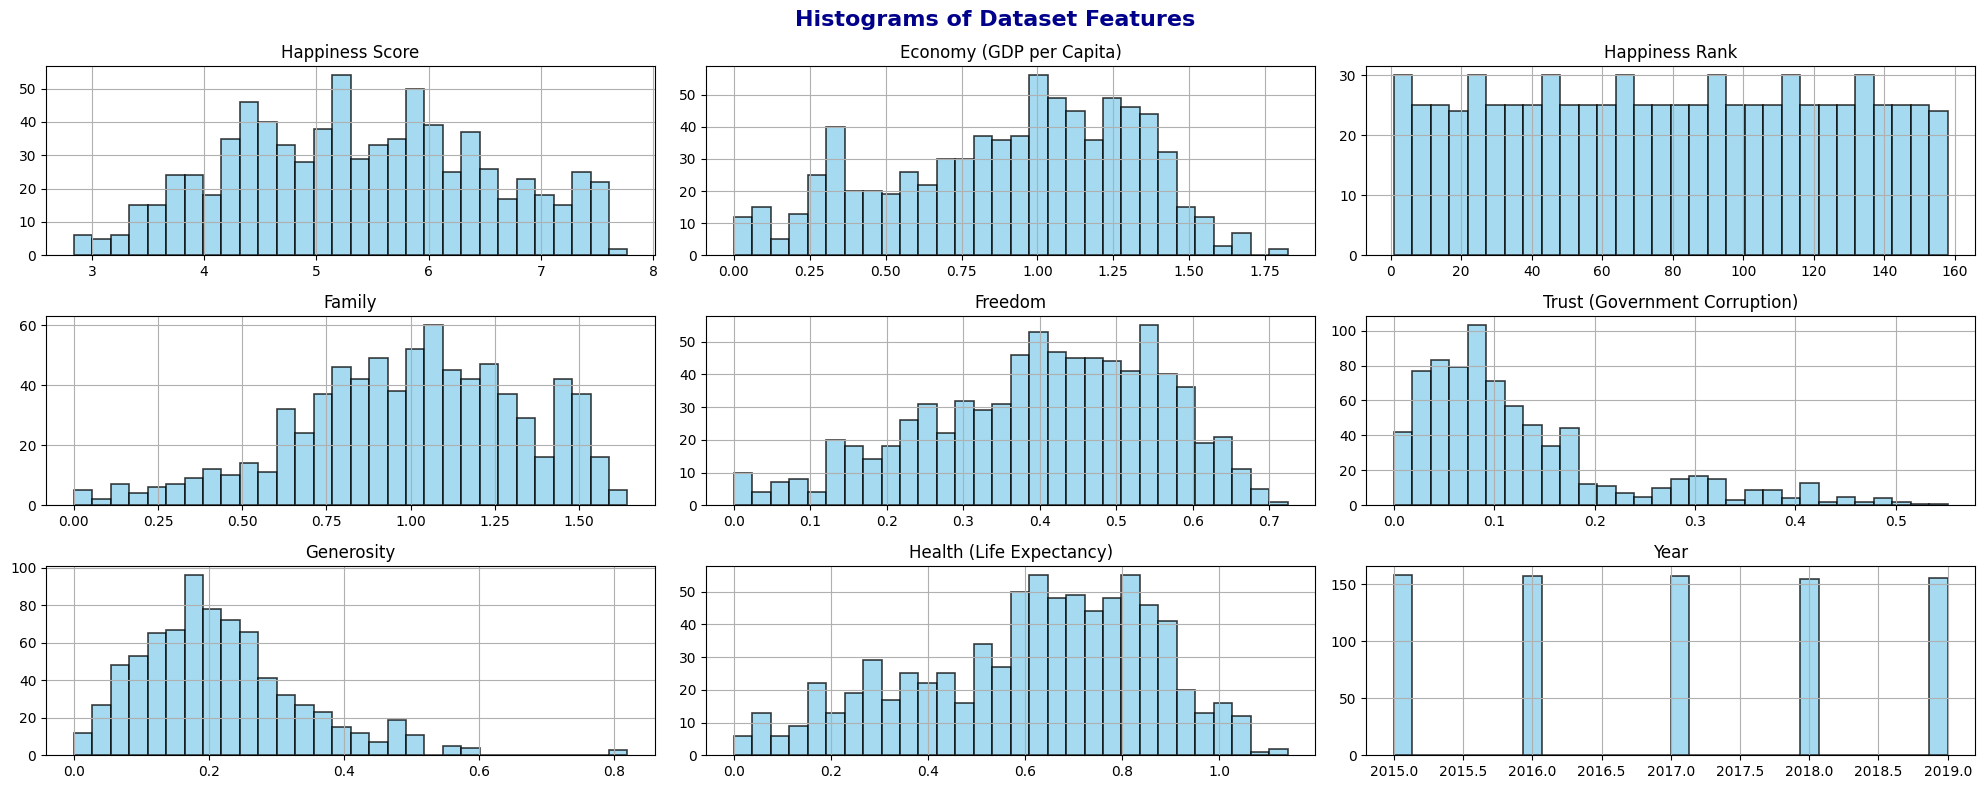

In [272]:
df_unido.hist(figsize=(20 ,8), bins=30, color="skyblue", edgecolor="black", alpha=0.75, grid=True, linewidth=1.2)
plt.suptitle("Histograms of Dataset Features", fontsize=16, fontweight="bold", color="darkblue")
plt.tight_layout()

plt.show()

Se elaboraron histogramas para analizar la distribución de variables numéricas como Happiness Score, Economy, Health, Family, Freedom, Trust y Generosity. Se observó que el Happiness Score tiene una distribución centrada en su media (~5.4), con un ligero sesgo a la izquierda. Economy, Health y Family presentan distribuciones más uniformes y medias entre 0.8 y 1.0, indicando valores consistentes entre países. En cambio, Trust y Generosity muestran medias bajas (~0.1–0.2) y distribuciones sesgadas hacia valores pequeños, lo que sugiere poca presencia de estos factores. Estos histogramas permiten identificar qué variables, como Economy y Health, son más representativas para el modelado.

In [273]:
correlation_matrix = df_unido.corr(numeric_only=True)
target_corr = correlation_matrix['Happiness Score'].sort_values(ascending=False)

print("Correlación con Happiness Score:")
print(target_corr)

Correlación con Happiness Score:
Happiness Score                  1.000000
Economy (GDP per Capita)         0.787876
Health (Life Expectancy)         0.738909
Family                           0.626205
Freedom                          0.549352
Trust (Government Corruption)    0.393080
Generosity                       0.139947
Year                             0.005955
Happiness Rank                  -0.992839
Name: Happiness Score, dtype: float64


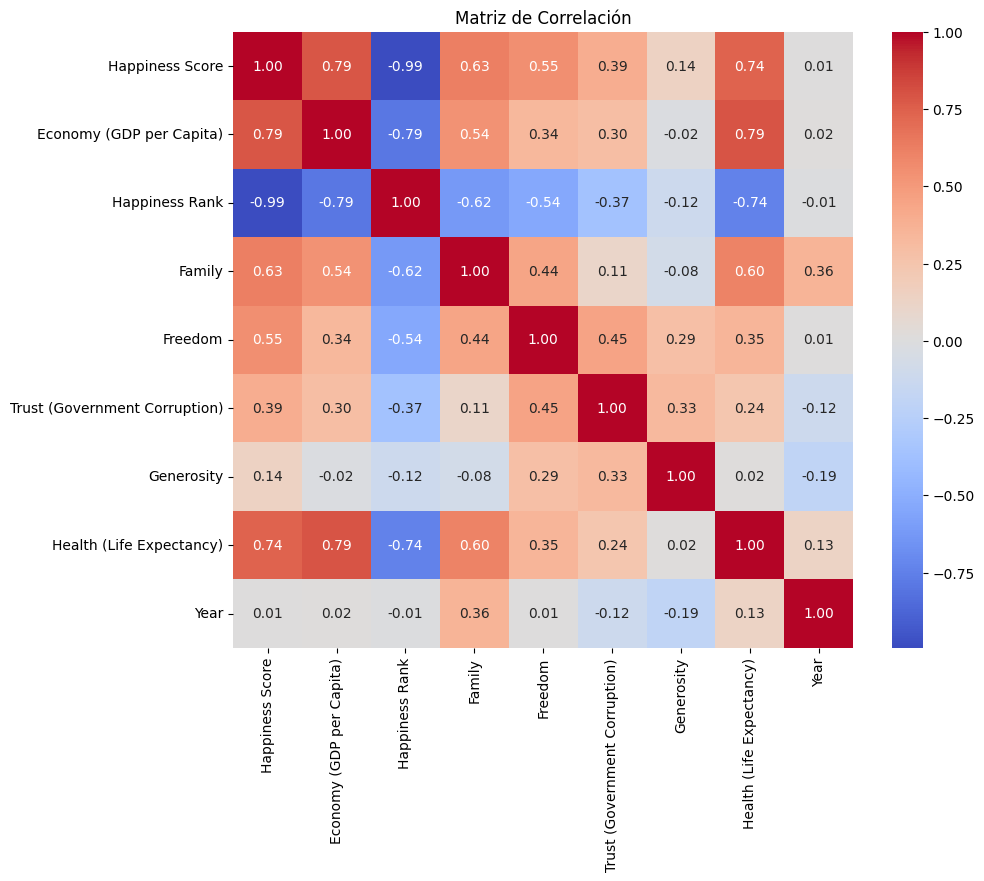

In [274]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

Se genera un mapa de calor con la correlación de Pearson entre variables numéricas. Happiness Score muestra alta correlación con Economy, Health y Family, destacándolas como predictores clave. Freedom tiene correlación moderada igual a Trust y especialmente Generosity presentan correlaciones bajas, justificando la exclusión de esta última. Happiness Rank se elimina por su correlación negativa casi perfecta con Happiness Score (-0.99), lo que indica redundancia.

In [275]:
threshold = 0.8
high_corr = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix != 1.0)]
print("Pares con correlación absoluta > 0.8:")
print(high_corr.dropna(how='all', axis=0).dropna(how='all', axis=1))

Pares con correlación absoluta > 0.8:
                 Happiness Score  Happiness Rank
Happiness Score              NaN       -0.992839
Happiness Rank         -0.992839             NaN


Hay una correlación negativa muy fuerte (-0.99) entre Happiness Rank y Happiness Score. Esto es esperado, ya que un mayor Happiness Score implica un menor Happiness Rank (un ranking más alto, es decir, un número menor). Happiness Rank es una variable derivada de Happiness Score, por lo que no aporta información nueva para un modelo de Machine Learning. Deberías eliminar Happiness Rank del análisis, ya que es redundante y puede introducir multicolinealidad.


In [276]:
df_unido.drop(columns=['Happiness Rank'], inplace=True)

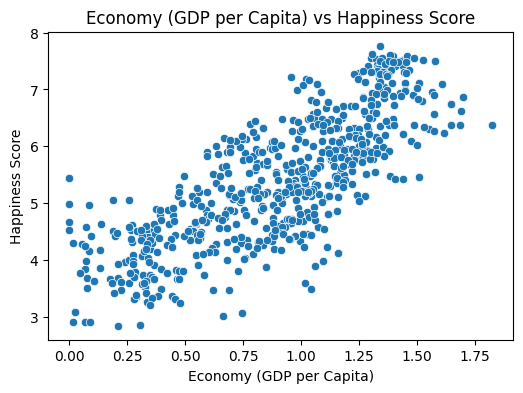

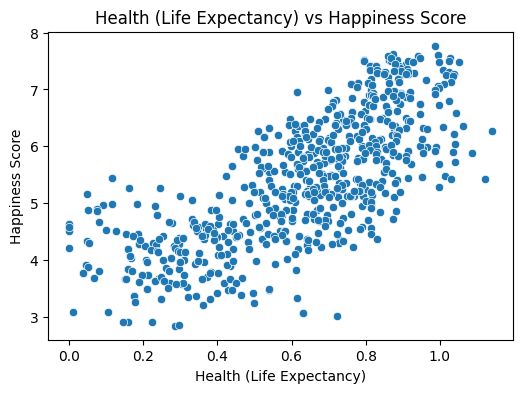

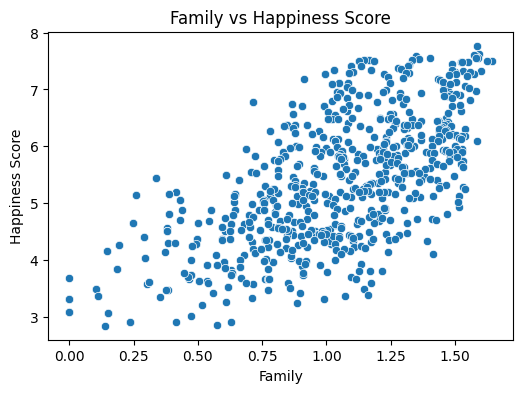

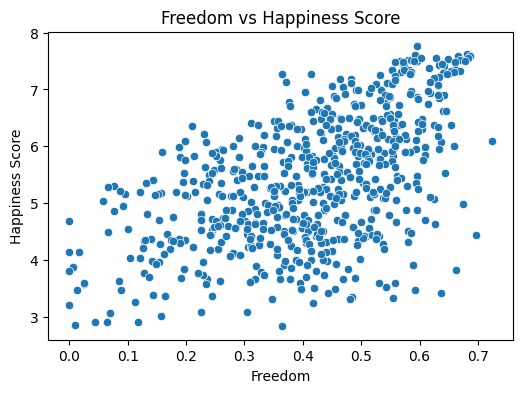

In [277]:
top_features = target_corr[abs(target_corr) > 0.3].index[1:5] 
for feature in top_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df_unido[feature], y=df_unido['Happiness Score'])
    plt.title(f'{feature} vs Happiness Score')
    plt.show()

Se crean gráficos de dispersión para analizar la relación entre Happiness Score y variables numéricas. Se observa una fuerte relación positiva con Economy, Health y Family, mientras que Freedom muestra una relación más débil y Trust y Generosity presentan poca asociación. Estos resultados refuerzan los hallazgos del mapa de calor, destacando a Economy y Health como predictores clave y respaldando la exclusión de Generosity. Además, la dispersión de los puntos entre países justifica incluir la variable Region para capturar diferencias geográficas.

#### Conclusion

Las visualizaciones colectivamente confirman la relevancia de Region, Economy (GDP per Capita), y Health (Life Expectancy) como factores clave que influyen en Happiness Score, respaldando su inclusión en el modelado. La estabilidad de Happiness Score entre los años 2015–2019, observada en los boxplots por Year, justifica la exclusión recomendada de Year como predictor.


In [278]:

X = df_unido.drop(['Country', 'Happiness Score'], axis=1, errors='ignore')
y = df_unido['Happiness Score']
selector = SelectKBest(score_func=f_regression, k=5)
X_new = selector.fit_transform(X.select_dtypes(include=['float64', 'int64']), y)
selected_features = X.select_dtypes(include=['float64', 'int64']).columns[selector.get_support()].tolist()
print("Características seleccionadas:", selected_features)

Características seleccionadas: ['Economy (GDP per Capita)', 'Family', 'Freedom', 'Trust (Government Corruption)', 'Health (Life Expectancy)']


Para identificar las variables numéricas más relevantes en la predicción de Happiness Score en el dataset del World Happiness Report (2015–2019), se aplica el método SelectKBest con f_regression, seleccionando Economy (GDP per Capita), Family, Health (Life Expectancy), Freedom, y Trust (Government Corruption) por su alta relevancia, mientras que Generosity se excluye debido a su menor impacto,

In [279]:
df_unido= df_unido.drop(columns=['Generosity'], axis=1, errors='ignore')

In [280]:
def anova_analysis(df_unido, cat_col, target_col='Happiness Score'):
    # Asegurar que no haya NaN en la columna categórica o target
    df_clean = df_unido[[cat_col, target_col]].dropna()
    groups = [df_clean[df_clean[cat_col] == category][target_col] for category in df_clean[cat_col].unique()]
    f_stat, p_value = f_oneway(*groups)
    print(f"ANOVA para {cat_col}: F={f_stat:.4f}, p-value={p_value:.4e}")
    return p_value

print("\nResultados de ANOVA:")
p_region = anova_analysis(df_unido, 'Region')
p_year = anova_analysis(df_unido, 'Year')
p_country = anova_analysis(df_unido, 'Country')


Resultados de ANOVA:
ANOVA para Region: F=138.5278, p-value=1.1250e-154
ANOVA para Year: F=0.0272, p-value=9.9857e-01
ANOVA para Country: F=100.8238, p-value=0.0000e+00


Mediante ANOVA, se evalúa la significancia de las variables categóricas Region, Year y Country en el dataset del (2015–2019) para decidir su inclusión; Region resulta muy significativa (F=138.5278, p-value=1.1250e-154) y se codifica en 10 columnas, Year no es significativa (F=0.0272, p-value=0.99857) y se recomienda excluir pese a su codificación, mientras que Country, aunque significativa (p-value=0), se descarta por su alta cardinalidad (~165 valores), priorizando así Region para el modelado y streaming con Kafka.

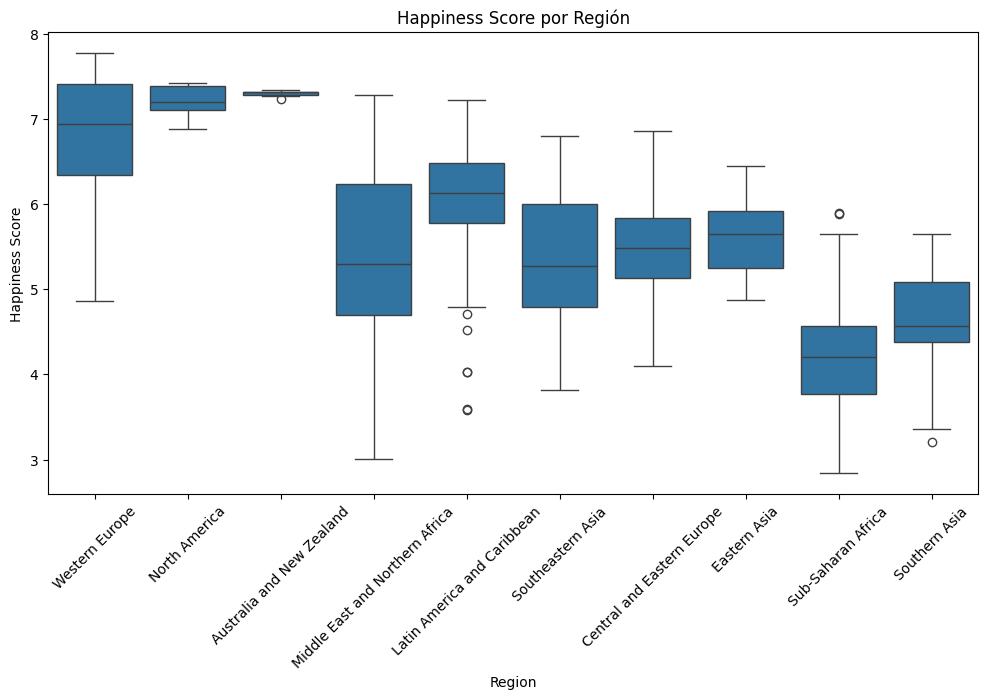

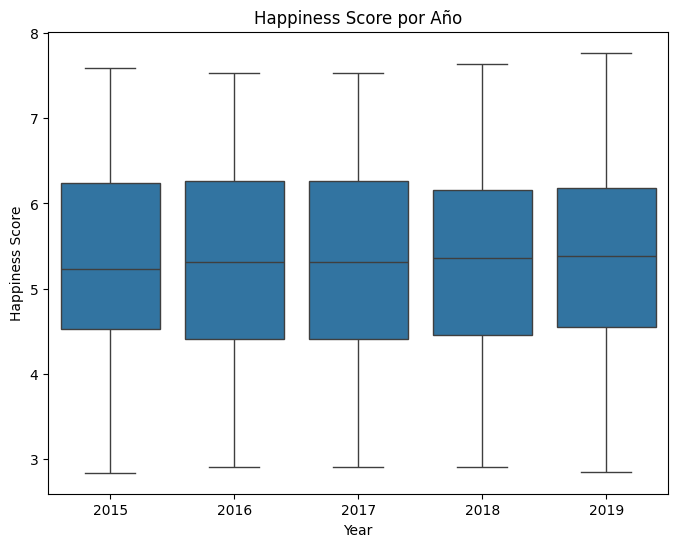

In [281]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Happiness Score', data=df_unido)
plt.xticks(rotation=45)
plt.title('Happiness Score por Región')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Year', y='Happiness Score', data=df_unido)
plt.title('Happiness Score por Año')
plt.show()

Se utilizan boxplots para analizar el Happiness Score según las variables Region y Year. Los resultados muestran diferencias claras entre regiones: Western Europe y North America presentan medianas altas (~7–8) y baja dispersión, mientras que Sub-Saharan Africa tiene medianas bajas (~3–4) y mayor variabilidad. En contraste, los boxplots por Year revelan medianas estables (~5.4) y poca variación entre 2015 y 2019.

In [282]:
df_unido.drop(columns=['Country'], inplace=True)
df_unido.drop(columns=['Year'], inplace=True)

Despues del analisis ANOVA se toma la decisionde eliminar country y year

In [283]:
df_unido.shape

(783, 7)

El daset al final queda con 783 dato y 7 columnas 

In [284]:
df_unido.columns

Index(['Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Freedom',
       'Trust (Government Corruption)', 'Health (Life Expectancy)', 'Region'],
      dtype='object')

Como vemos, nos quedamos con las siguientes columnas principales para el análisis:

- Happiness Score  
- Economy (GDP per Capita)  
- Family  
- Freedom  
- Trust (Government Corruption)  
- Health (Life Expectancy)  
- Region  

Se guardan los datos en csv pra depues con este csv hacer el entramoento del modelos, pero anstes vamos a aplicar OneHotEncode

In [285]:
df_encoded = pd.get_dummies(df_unido, columns=['Region'], dtype=int)

Para preparar un dataset numérico apto para el modelado en el World Happiness Report (2015–2019), se aplica one-hot encoding a Region, generando 10 columnas, y a Year, creando 5 columnas, mientras que se eliminan Generosity, Happiness Rank, Country, y posteriormente Year por su baja significancia, resultando en df_encoded con 15 columnas predictivas (5 numéricas: Economy, Family, Health, Freedom, Trust; 10 de Region_) y Happiness Score como variable objetivo, listo para análisis y streaming con Kafka.

In [286]:
df_encoded.to_csv('../data/processed/df_clean.csv', index=False)

Se guarda el dataset limpio en la ruta ../data/processed/df_clean.csv sin incluir el índice.






